In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2,])
df.columns=['class label', 'beer', 'marlic acid']


In [3]:
df.head()

,class label,beer,marlic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class label  178 non-null    int64  
 1   beer         178 non-null    float64
 2   marlic acid  178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


<Axes: xlabel='class label', ylabel='Density'>

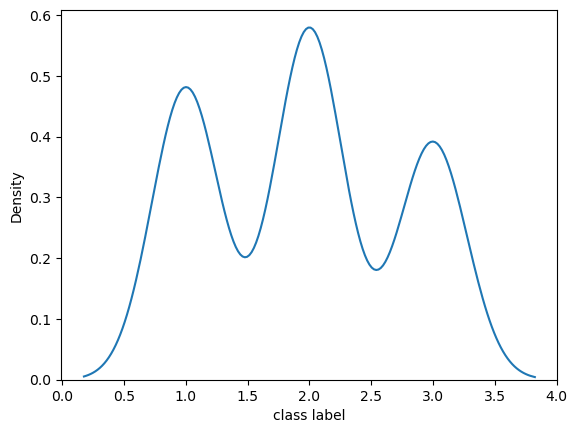

In [5]:
sns.kdeplot(df['class label'])

<Axes: xlabel='beer', ylabel='Density'>

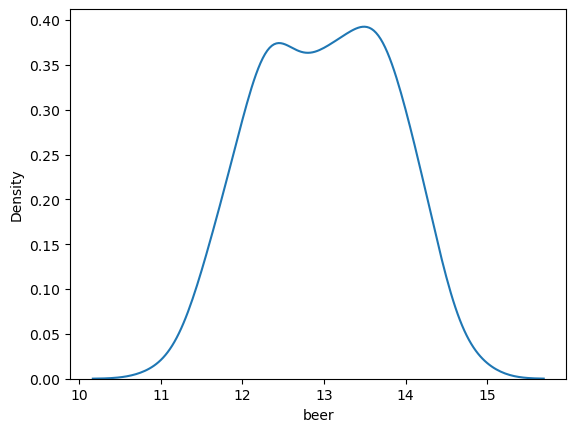

In [6]:
sns.kdeplot(df['beer'])

<Axes: xlabel='beer', ylabel='marlic acid'>

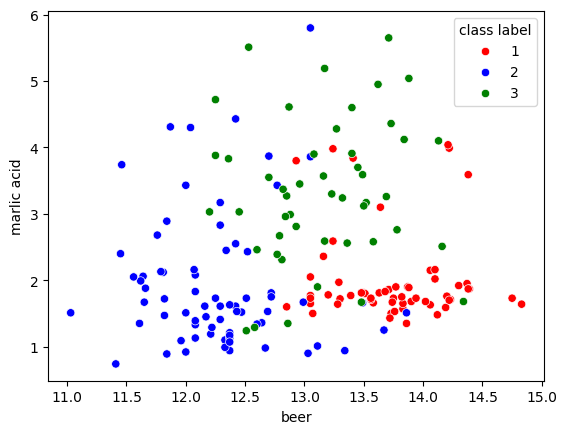

In [7]:
color_dict = {1:'red', 3:'green', 2:'blue'}
sns.scatterplot(x=df['beer'], y=df['marlic acid'], hue=df['class label'], palette=color_dict)

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(df.drop('class label', axis=1),
                                                    df['class label'],
                                                    test_size=0.4,random_state=0)
X_train.shape, X_test.shape

((106, 2), (72, 2))

In [9]:
from sklearn.preprocessing import MinMaxScaler
sclr = MinMaxScaler()
sclr.fit(X_train)
xtrainscl = sclr.transform(X_train)
xtestscl = sclr.transform(X_test)

In [10]:
np.round(X_train.describe())

,beer,marlic acid
count,106.0,106.0
mean,13.0,2.0
std,1.0,1.0
min,11.0,1.0
25%,12.0,2.0
50%,13.0,2.0
75%,14.0,3.0
max,15.0,6.0


In [11]:
xtrainscl = pd.DataFrame(xtrainscl, columns=X_train.columns)
xtestscl = pd.DataFrame(xtestscl, columns=X_test.columns)

In [12]:
np.round(xtrainscl.describe())

,beer,marlic acid
count,106.0,106.0
mean,1.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,1.0,0.0
75%,1.0,0.0
max,1.0,1.0


Text(0.5, 1.0, 'After')

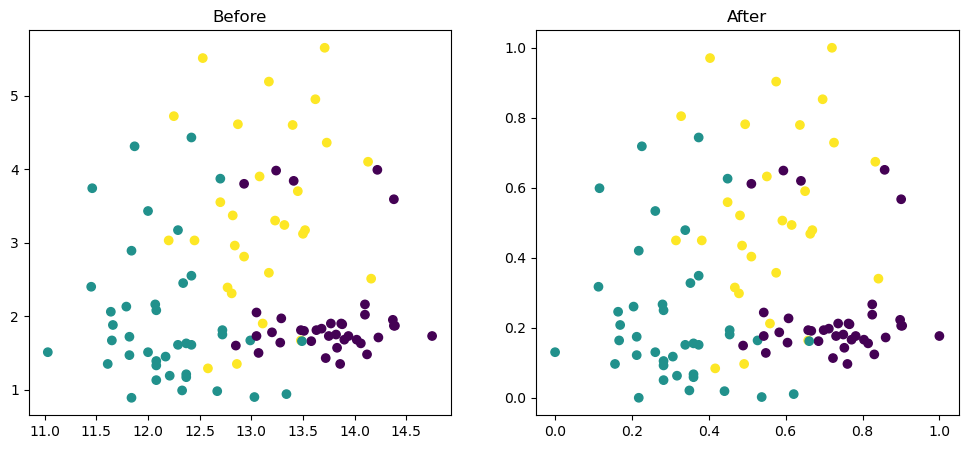

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['beer'], X_train['marlic acid'], c =Y_train)
ax1.set_title("Before")
ax2.scatter(xtrainscl['beer'], xtrainscl['marlic acid'], c = Y_train)
ax2.set_title("After")